# Real Image Editing — One-Shot Colab Notebook

End-to-end run on **one image + one instruction**, producing two paths and three visualizations.

**Method path** (PEZ + P2P):
  1. PEZ-1 inversion → continuous source embeddings + per-timestep null-text
  2. PEZ-2 instruction-conditioned target prompt sweep over Knob 1 (`λ_instruction`, `γ_anchor`)
  3. P2P + LocalBlend edit sweep over Knob 2 (`cross_replace_steps`)

**Baseline path** (BLIP + manual prompt):
  1. BLIP captions the source
  2. User-supplied target prompt (set after seeing the caption)
  3. Standard P2P + LocalBlend edit over Knob 2

**Visualizations:**
  1. Prompt evolution PEZ-1 → PEZ-2 across Knob 1
  2. 2D matrix: rows = Knob 1 (PEZ-2 prompts), cols = Knob 2 (cross_replace_steps)
  3. 1D row: BLIP-source + manual-target P2P, cols = same Knob 2 axis as #2

**Outputs saved to `outputs/colab_oneshot/`:** source.png, every grid cell as an individual PNG, the composed Vis #2 / Vis #3 figures, the Vis #1 prompt-diff HTML, and a `run_metadata.json` with all prompts, knob settings, BLIP caption, and model IDs.

**Recommended run order:** the BLIP-caption cell runs in seconds and prints the caption *before* PEZ-1 (~70 min) starts, so you can write a good `MANUAL_TARGET_PROMPT` while looking at the caption.

**Expected runtime on A100:** ~90–150 min cold (PEZ-1 dominates). PEZ-1 and PEZ-2 results are cached, so re-runs with the same image/instruction are fast.

**GPU:** A100 (40 GB) recommended. Cold weights total ~6 GB (SD1.5 + CLIP-L/14 + BLIP); T4 (15 GB) should fit comfortably.

**Authentication:** none required — SD1.5 (the public mirror) and CLIP-L/14 / BLIP are all open-access. Switching `edit_config.sd_model` to a gated model (e.g. `stabilityai/stable-diffusion-2-1-base`) would re-introduce the `HF_TOKEN` requirement.

In [ ]:
# 1. Clone repo and install deps not already on Colab
import os
if not os.path.isdir('real-image-editing'):
    !git clone https://github.com/beratcelik1/real-image-editing.git
%cd real-image-editing
!git submodule update --init --recursive 2>/dev/null
# Install non-Colab-default deps. We DO NOT pin transformers /
# huggingface_hub here — pinning to old versions creates conflicts
# with Colab's pre-installed packages (diffusers, gradio, peft all
# need newer huggingface_hub). The known regression in transformers
# >= ~4.45 (404 on additional_chat_templates for CLIPTokenizer) is
# handled by a code-level monkey-patch in src/utils.py at import
# time, which is version-agnostic. So just install diffusers and
# friends with whatever versions Colab and pip resolve to.
!pip install -q torch diffusers transformers accelerate safetensors Pillow numpy torchvision scikit-image tqdm matplotlib pandas lpips open-clip-torch

import transformers as _t, huggingface_hub as _hf
print(f'transformers={_t.__version__}, huggingface_hub={_hf.__version__}  (chat-template 404 patch applies regardless of versions)')

import torch
assert torch.cuda.is_available(), 'GPU runtime required (Runtime → Change runtime type → GPU)'
print(f'GPU: {torch.cuda.get_device_name(0)}, VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Cloning into 'real-image-editing'...
remote: Enumerating objects: 524, done.
remote: Counting objects: 100% (524/524), done.
remote: Compressing objects: 100% (250/250), done.
remote: Total 524 (delta 334), reused 447 (delta 258), pack-reused 0 (from 0)
Receiving objects: 100% (524/524), 2.97 MiB | 21.28 MiB/s, done.
Resolving deltas: 100% (334/334), done.
/content/real-image-editing
Submodule path 'external/pez': checked out 'f22a1bec01991d94697304443cacbd66e0167e6b'
Submodule path 'external/plug-and-play': checked out '4e7f703df5f5746011127f058e07ece415564910'
Submodule path 'external/prompt-to-prompt': checked out '9c472e44aa1b607da59fea94820f7be9480ec545'
transformers=5.0.0, huggingface_hub=1.11.0  (chat-template 404 patch applies regardless of versions)
GPU: NVIDIA A100-SXM4-40GB, VRAM: 42.4 GB


In [2]:
# 2. HuggingFace login (OPTIONAL).
#    SD1.5, CLIP-L/14, and BLIP are all open-access — no token needed.
#    This cell is a no-op unless an HF_TOKEN secret is set, in which
#    case it logs in (handy if you switch to a gated model like
#    stabilityai/stable-diffusion-2-1-base).
from huggingface_hub import login
_token = None
try:
    from google.colab import userdata
    try:
        _token = userdata.get('HF_TOKEN')
    except Exception:
        _token = None
except ImportError:
    _token = os.environ.get('HF_TOKEN')

if _token:
    login(token=_token)
    print('Logged in to HuggingFace (HF_TOKEN found).')
else:
    print('No HF_TOKEN configured — proceeding unauthenticated. '
          'Fine for the default SD1.5 + CLIP-L + BLIP models.')

Logged in to HuggingFace (HF_TOKEN found).


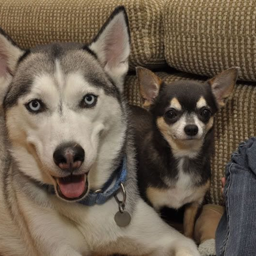

In [3]:
# 3. Inputs — change these for your run.
#    The MANUAL_TARGET_PROMPT for the BLIP baseline lives in its own cell
#    further down so you can set it AFTER seeing the BLIP caption.

# 3a. Source image. Default: the local husky+chihuahua example
#     (cropped to 512x512 in data/examples/). To use a different image,
#     either set IMAGE_PATH to another local file or set IMAGE_URL and
#     IMAGE_PATH together (auto-fetch fallback below).
IMAGE_PATH = 'data/examples/huskychihuahua_512.png'
IMAGE_URL = ''   # blank when using a pre-prepped local file
if IMAGE_URL and not os.path.isfile(IMAGE_PATH):
    os.makedirs(os.path.dirname(IMAGE_PATH), exist_ok=True)
    !wget -q -O {IMAGE_PATH} "{IMAGE_URL}"

# 3b. Method-path edit instruction (used by PEZ-2)
INSTRUCTION = 'two stuffed animals on a couch'   # rich description (proposal §8a):
                                                  # the cosine-cancellation property protects
                                                  # 'couch' content already in PEZ-1's prompt;
                                                  # drift concentrates on the husky/chihuahua
                                                  # → stuffed-animal axis. Multi-subject
                                                  # test for §3.2; chosen as a more
                                                  # visually distinct edit than dogs→cats
                                                  # which CLIP puts very near each other.

# 3c. Knob 1 grids — PEZ-2 hyperparameters. The full (λ, γ) sweep
#     defined in RESEARCH_PROPOSAL.md §4.5. Visualizations use λ as the
#     horizontal axis and γ as the vertical axis.
LAMBDA_GRID = [2.0, 5.0, 10.0]          # λ_instruction. Bumped from [0.5, 1, 2]
                                        # because at the lower range, λ·L_instr's
                                        # gradient was being drowned by SDS gradient
                                        # noise on L_source — PEZ-2 stayed at the
                                        # warm-start (no visible edit even with
                                        # γ=1, where L_anchor is essentially off).
                                        # λ=10 is the aggressive end where alignment
                                        # may break; cf. RESEARCH_PROPOSAL.md §4.2.
GAMMA_GRID  = [10.0]                     # γ_anchor (single value for v1 iteration).
                                        # γ=10 ≈ nearly free drift under L_anchor=.mean()
                                        # — instruction dominates, anchor barely active.
                                        # Trimmed from [10, 100, 1000] to a single value
                                        # because the prior sweep showed γ ≥ 100 over-
                                        # constrained drift (per-position cosines stayed
                                        # >> τ everywhere → no P2P swap unmapped). Re-add
                                        # higher values once edits are reliably visible
                                        # at γ=10 and we want to study the anchor knob.

# 3d. Knob 2 grid — cross_replace_steps. Secondary axis: rendered as
#     three (λ × γ) panels (one per cross_replace_steps value), GIF
#     frames, and strip-comparison columns.
KNOB_2_GRID = [0.6, 0.4, 0.2]   # recentered on Hertz's word-swap recommendation
                                # of 0.4 (was [0.8, 0.5, 0.3], biased toward
                                # the additive-edit value of 0.8)

# Per-(image, instruction) cost (3×3 grid): 9 PEZ-2 runs +
# 27 edits ≈ 1-1.5 h with adaptive early stopping in pez_search.
# Cost-aware ordering (PEZ-2 outer, editing inner) keeps PEZ-2
# amortized across cross_replace_steps values.

# 3e. Output directory (everything saved here for offline review)
from pathlib import Path
OUTPUT_DIR = Path('outputs/colab_oneshot')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

from PIL import Image
Image.open(IMAGE_PATH).resize((256, 256))

In [4]:
# 4. Load models: SD1.5 + CLIP-L/14 (for PEZ-1 image features) + BLIP (for caption baseline)
#
# CLIP-variant choice: SD1.5's text encoder is OpenAI CLIP-L/14 (hidden_size=768).
# The CLIP loaded here MUST match SD's text-encoder dim or `clip_similarity_loss`
# errors on the cosine-similarity dot product (SD-pooled vs. clip_image_features).
# We use OpenAI's CLIP-L/14 — same architecture SD1.5 uses internally, with
# a vision tower for clip_image_features.
from src.utils import (
    load_sd_components, load_image, encode_image, decode_latent,
    get_text_embeddings, get_uncond_embeddings, get_device,
)
from src.config import load_pez_1, load_pez_2, load_local_blend, load_edit

device = get_device()

edit_config = load_edit()
print(f'Loading {edit_config.sd_model}...')
unet, vae, text_encoder, tokenizer, scheduler = load_sd_components(
    model_id=edit_config.sd_model,
)
sd_components = {
    'unet': unet, 'vae': vae, 'text_encoder': text_encoder,
    'tokenizer': tokenizer, 'scheduler': scheduler,
}

# CLIP-L/14 (HF format) — matches SD1.5's 768-dim text encoder.
from transformers import CLIPModel, CLIPProcessor
CLIP_HF_ID = 'openai/clip-vit-large-patch14'
clip_model = CLIPModel.from_pretrained(CLIP_HF_ID).to(device).eval()
clip_processor = CLIPProcessor.from_pretrained(CLIP_HF_ID)
text_projection = clip_model.text_projection  # nn.Linear(768, 768)

# BLIP for the baseline caption
from transformers import BlipForConditionalGeneration, BlipProcessor
BLIP_HF_ID = 'Salesforce/blip-image-captioning-large'
blip_processor = BlipProcessor.from_pretrained(BLIP_HF_ID)
blip_model = BlipForConditionalGeneration.from_pretrained(BLIP_HF_ID).to(device).eval()

source_image = load_image(IMAGE_PATH, size=512)
with torch.no_grad():
    inputs = clip_processor(images=source_image, return_tensors='pt').to(device)
    # Compute joint-space image features explicitly via vision_model +
    # visual_projection. `clip_model.get_image_features(**inputs)` returns
    # BaseModelOutputWithPooling (not a tensor) on some transformers
    # versions, which breaks downstream `target_image_features.to(...)`
    # calls inside clip_similarity_loss. Calling the two pieces directly
    # is version-robust and yields the same projected tensor.
    vision_out = clip_model.vision_model(pixel_values=inputs['pixel_values'])
    pooled = (
        vision_out.pooler_output if hasattr(vision_out, 'pooler_output')
        else vision_out[1]
    )
    clip_image_features = clip_model.visual_projection(pooled)
assert isinstance(clip_image_features, torch.Tensor), (
    f'expected tensor, got {type(clip_image_features).__name__}'
)

# Free the rest of the CLIP vision/text weights from VRAM. text_projection was
# captured above as a separate reference and stays alive on device.
del clip_model
torch.cuda.empty_cache()
print('Models loaded.')
print(f'  clip_image_features: shape={tuple(clip_image_features.shape)} '
      f'(expected (1, 768) for CLIP-L/14)')

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Loading stable-diffusion-v1-5/stable-diffusion-v1-5...


tokenizer_config.json:   0%|          | 0.00/806 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.88G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/616 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-large
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Models loaded.
  clip_image_features: shape=(1, 768) (expected (1, 768) for CLIP-L/14)


In [5]:
# 5. BLIP caption — runs in seconds. Look at the printed caption, then
#    set MANUAL_TARGET_PROMPT in the next cell. Doing this BEFORE PEZ-1
#    means you decide the baseline target while PEZ-1 is still queued.
with torch.no_grad():
    inputs = blip_processor(images=source_image, return_tensors='pt').to(device)
    out = blip_model.generate(**inputs, max_length=30)
BLIP_SOURCE_PROMPT = blip_processor.decode(out[0], skip_special_tokens=True)
print(f'BLIP caption: {BLIP_SOURCE_PROMPT!r}')
print('\n→ Edit MANUAL_TARGET_PROMPT in the next cell based on this caption.')

# Free BLIP weights — we already have the caption string.
del blip_model, blip_processor
torch.cuda.empty_cache()

BLIP caption: 'two dogs are sitting on a couch with their owners legs crossed'

→ Edit MANUAL_TARGET_PROMPT in the next cell based on this caption.


In [6]:
# 6. Manual target prompt for the BLIP baseline path. Edit this AFTER
#    seeing the caption above. The baseline runs `BLIP_SOURCE_PROMPT →
#    MANUAL_TARGET_PROMPT` through standard P2P (no PEZ).
# Plushies-scenario override. We keep the BLIP source caption ("two dogs")
# matching the actual image content but — like before — we keep BLIP's
# hallucinated "with their owners legs crossed" tail because that's what
# BLIP actually outputs for this image; faithful captioning is part of
# what we're comparing against. Target swaps dogs → plushies, mirroring
# the method-path INSTRUCTION direction.
BLIP_SOURCE_PROMPT  = 'two dogs are sitting on a couch with their owners legs crossed'
MANUAL_TARGET_PROMPT = 'two plushies are sitting on a couch with their owners legs crossed'   # BLIP-baseline target;
                                                # mirror the method-path INSTRUCTION
print(f'Source (from BLIP): {BLIP_SOURCE_PROMPT!r}')
print(f'Target (manual):    {MANUAL_TARGET_PROMPT!r}')

Source (from BLIP): 'two dogs are sitting on a couch with their owners legs crossed'
Target (manual):    'two plushies are sitting on a couch with their owners legs crossed'


In [7]:
# 10. Helper: thin wrapper around src.pipeline.run_p2p_edit that
#     applies a Knob-2 override to the loaded EditConfig before
#     dispatching.
#
# Source-side invariants (z_T from DDIM inversion, the CLIP-encoded
# source/uncond embeddings) don't change across the 3D sweep cells —
# they depend only on (image, source_embeddings). prepare_p2p_inputs
# computes all three once; run_edit threads them in via run_p2p_edit's
# cached_* kwargs so the inner loop avoids ~26 redundant DDIM
# inversions + 26 redundant CLIP-text encodes (Bug #6 / #8 fixes).
from src.pipeline import (
    run_p2p_edit,
    prepare_p2p_inputs,
    encode_continuous_prompt,
    _apply_overrides_nested,
)
import torch as _torch

# Config-derived constants used by both the BLIP baseline (Phase A)
# and the method path (Phase B). Defined here so downstream cells
# don't have to re-load the edit config or look up dtype/device.
_base_edit_cfg = load_edit()
_dtype_map = {'float16': _torch.float16, 'float32': _torch.float32, 'bfloat16': _torch.bfloat16}
_dtype = _dtype_map[_base_edit_cfg.dtype]
_device = _torch.device(_base_edit_cfg.device)

def run_edit(
    source_emb,
    target_emb,
    cross_replace_steps,
    *,
    use_null_text=True,
    cached_source_emb=None,
    cached_target_emb=None,
    cached_uncond_emb=None,
    cached_z_T=None,
    cached_alignment=None,
    cached_null_text=None,
):
    """Edit `source_image` from source embeddings to target embeddings at
    the requested cross_replace_steps. Returns the edited PIL image.

    `use_null_text=True` (default) threads PEZ-1's null_text + the
    pre-computed pez_inputs (z_T, source_emb, uncond_emb) for faithful
    Mokady-style source reconstruction at edit time. Set False for the
    BLIP baseline since it uses different source embeddings + has no
    PEZ-1 null-text.

    `cached_target_emb` / `cached_alignment` let callers hoist target-
    side work out of the inner cross_replace_steps loop (since both
    depend only on (source_emb, target_emb), invariant across the
    inner sweep).
    """
    edit_cfg = _apply_overrides_nested(
        _base_edit_cfg,
        {'cross_attention.cross_replace_steps': cross_replace_steps},
    )
    if use_null_text:
        nt = cached_null_text if cached_null_text is not None else null_text_per_timestep
        src_e = cached_source_emb if cached_source_emb is not None else pez_inputs['source_emb']
        unc_e = cached_uncond_emb if cached_uncond_emb is not None else pez_inputs['uncond_emb']
        z_T_v = cached_z_T if cached_z_T is not None else pez_inputs['z_T']
    else:
        nt = None
        src_e = cached_source_emb
        unc_e = cached_uncond_emb
        z_T_v = cached_z_T
    return run_p2p_edit(
        image=source_image,
        source_embeddings=source_emb,
        target_embeddings=target_emb,
        sd_components=sd_components,
        edit_config=edit_cfg,
        local_blend_config=load_local_blend(),
        null_text_per_timestep=nt,
        cached_z_T=z_T_v,
        cached_source_emb=src_e,
        cached_target_emb=cached_target_emb,
        cached_uncond_emb=unc_e,
        cached_alignment=cached_alignment,
    )


---
## Phase A — BLIP baseline (run first to sanity-check P2P + null-text inversion)

In [8]:
# 13. Tokenize the BLIP source caption + manual target, then look up
#     vocabulary embeddings to feed into run_edit. (BLIP caption was
#     generated way back in cell 5; MANUAL_TARGET_PROMPT was set in cell 6.)
import torch as _torch

_token_emb = sd_components['text_encoder'].text_model.embeddings.token_embedding
_emb_device = _token_emb.weight.device

def _ids_to_embeddings(ids):
    """Look up CLIP vocabulary embeddings for a token-ID list. Returns [1, N, 768]."""
    ids_t = _torch.tensor(ids, device=_emb_device)
    return _token_emb(ids_t).unsqueeze(0).detach()

blip_src_ids = tokenizer.encode(BLIP_SOURCE_PROMPT, add_special_tokens=False)
blip_tgt_ids = tokenizer.encode(MANUAL_TARGET_PROMPT, add_special_tokens=False)

# Pad/truncate to the same length so warm-start-style alignment works.
_n = max(len(blip_src_ids), len(blip_tgt_ids))
def _pad(ids, n):
    pad_id = tokenizer.pad_token_id or tokenizer.eos_token_id
    return list(ids) + [pad_id] * (n - len(ids))
blip_src_ids = _pad(blip_src_ids, _n)
blip_tgt_ids = _pad(blip_tgt_ids, _n)

blip_src_embeddings = _ids_to_embeddings(blip_src_ids)
blip_tgt_embeddings = _ids_to_embeddings(blip_tgt_ids)

print(f'Source ({_n} tokens): {BLIP_SOURCE_PROMPT!r}')
print(f'Target ({_n} tokens): {MANUAL_TARGET_PROMPT!r}')

Source (13 tokens): 'two dogs are sitting on a couch with their owners legs crossed'
Target (13 tokens): 'two plushies are sitting on a couch with their owners legs crossed'


In [9]:
# 13b. BLIP baseline: null-text-optimized DDIM inversion (Mokady et al. 2023).
#
# Same null-text machinery PEZ-1 uses internally, applied to the BLIP
# source caption + manual target. This makes the BLIP→manual P2P baseline
# apples-to-apples with the method path: both get Mokady-style null-text
# inversion, so the only thing being compared is *prompt source*
# (PEZ-2 continuous embeddings vs BLIP-discrete + manual-discrete).
#
# Cost: ~5-10 min cold; cached on (image bytes + BLIP_SOURCE_PROMPT +
# DDIM/null-text hyperparams) so re-runs are instant.
import hashlib
import torch as _torch
from src.inversion import ddim_inversion, null_text_optimization
from src.utils import get_uncond_embeddings as _get_uncond, encode_image as _encode_image

_blip_uncond_emb = _get_uncond(tokenizer, sd_components['text_encoder'], device)
_blip_image_latent = _encode_image(source_image, sd_components['vae'], device).to(dtype=_dtype)

# Encode BLIP source-prompt embeddings through CLIP text model — used
# both as conditioning for the inversion AND cached for the edit loop.
_blip_src_dev = blip_src_embeddings.to(device=_device)
_blip_src_emb = encode_continuous_prompt(
    _blip_src_dev, sd_components['text_encoder'], tokenizer, _dtype,
)

# Cache key: source-side only (target prompt doesn't affect inversion).
_h = hashlib.sha256()
_h.update(source_image.tobytes())
_h.update(BLIP_SOURCE_PROMPT.encode('utf-8'))
_nt_cfg = _base_edit_cfg.ddim.null_text
_h.update(
    f'steps={_base_edit_cfg.ddim.num_steps}|cfg={_base_edit_cfg.ddim.cfg_scale}|'
    f'opt_steps={_nt_cfg["opt_steps"]}|lr={_nt_cfg["lr"]}'.encode('utf-8')
)
_blip_null_cache_path = Path('cache/blip_null_text') / f'{_h.hexdigest()[:16]}.pt'

if _blip_null_cache_path.exists():
    print(f'BLIP null-text cache hit: {_blip_null_cache_path}')
    _cached = _torch.load(_blip_null_cache_path, map_location='cpu')
    blip_z_T = _cached['z_T'].to(device=_device)
    blip_null_text = [nt.to(device=_device) for nt in _cached['null_text']]
else:
    print('BLIP null-text cold run (~5-10 min)...')
    # CFG=1 for inversion (Mokady-style); the optimized null-text
    # corrects the residual at edit-time CFG.
    _, _blip_latents_traj = ddim_inversion(
        _blip_image_latent, _blip_src_emb, _blip_uncond_emb,
        sd_components['unet'], sd_components['scheduler'],
        num_steps=_base_edit_cfg.ddim.num_steps,
        cfg_scale=1.0,
    )
    blip_z_T = _blip_latents_traj[-1]
    blip_null_text = null_text_optimization(
        _blip_latents_traj, _blip_src_emb, _blip_uncond_emb,
        sd_components['unet'], sd_components['scheduler'],
        num_steps=_base_edit_cfg.ddim.num_steps,
        cfg_scale=_base_edit_cfg.ddim.cfg_scale,
        opt_steps=_nt_cfg['opt_steps'],
        lr=_nt_cfg['lr'],
    )
    _blip_null_cache_path.parent.mkdir(parents=True, exist_ok=True)
    _torch.save({
        'z_T': blip_z_T.detach().cpu(),
        'null_text': [nt.detach().cpu() for nt in blip_null_text],
    }, _blip_null_cache_path)
    print(f'Saved → {_blip_null_cache_path}')

print(f'  BLIP null-text: {len(blip_null_text)} timesteps')
print(f'  BLIP z_T shape: {tuple(blip_z_T.shape)}')

BLIP null-text cold run (~5-10 min)...


Null-text Optimization: 100%|██████████| 50/50 [01:06<00:00,  1.32s/it]

Saved → cache/blip_null_text/b5989dc7701dfe42.pt
  BLIP null-text: 50 timesteps
  BLIP z_T shape: (1, 4, 64, 64)


In [12]:
# 14. 1D sweep — BLIP source + manual target across the same Knob 2
#     axis as vis #2. Threads BLIP-side null-text + z_T (computed in 13b)
#     so the baseline gets Mokady-style inversion just like the method path.
#
#     Hoist BLIP target encoding + alignment out of the inner loop —
#     they don't change across cross_replace_steps (Bug #8 fix).
#     (BLIP source encoding _blip_src_emb was already hoisted in cell 13b
#     because the inversion needed it; reusing that here.)
import torch as _torch
from src.splice.align import align_pez_prompts as _align

_blip_tgt_dev = blip_tgt_embeddings.to(device=_device)
_blip_tgt_emb = encode_continuous_prompt(
    _blip_tgt_dev, sd_components['text_encoder'], tokenizer, _dtype,
)
_blip_src_for_align = _blip_src_dev.squeeze(0) if _blip_src_dev.ndim == 3 else _blip_src_dev
_blip_tgt_for_align = _blip_tgt_dev.squeeze(0) if _blip_tgt_dev.ndim == 3 else _blip_tgt_dev
_blip_align = _align(
    _blip_src_for_align, _blip_tgt_for_align,
    threshold=_base_edit_cfg.alignment_threshold,
    method=_base_edit_cfg.alignment_method,
)

blip_results = {}
for k2_val in KNOB_2_GRID:
    print(f'BLIP edit [cross_replace={k2_val}]')
    blip_results[k2_val] = run_edit(
        blip_src_embeddings, blip_tgt_embeddings, k2_val,
        use_null_text=True,
        cached_source_emb=_blip_src_emb,
        cached_target_emb=_blip_tgt_emb,
        cached_alignment=_blip_align,
        cached_null_text=blip_null_text,
        cached_uncond_emb=_blip_uncond_emb,
        cached_z_T=blip_z_T,
    )


BLIP edit [cross_replace=0.6]
BLIP edit [cross_replace=0.4]
BLIP edit [cross_replace=0.2]


Saved Vis #3 → outputs/colab_oneshot/vis3_baseline_row.png


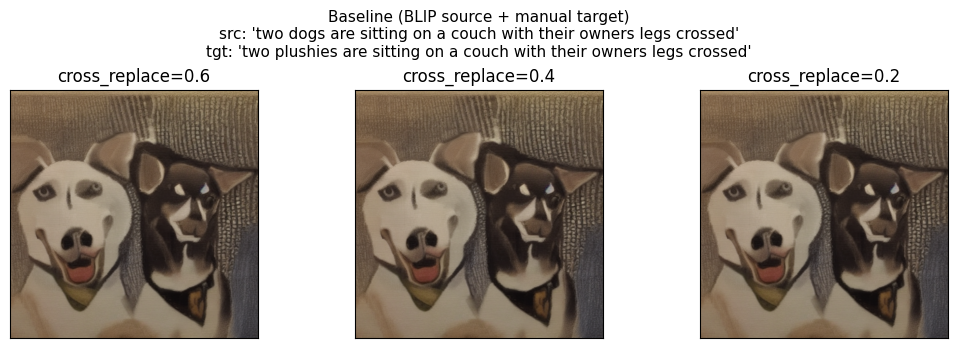

In [16]:
# 15. Visualization 3 — 1D BLIP edit row (shares Knob 2 axis with vis #2).
#     Saves the composed figure as a PNG.
import base64
import difflib
import io

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from IPython.display import display, HTML

fig, axes = plt.subplots(1, len(KNOB_2_GRID), figsize=(3.5 * len(KNOB_2_GRID), 3.5), squeeze=False)
for j, k2_val in enumerate(KNOB_2_GRID):
    ax = axes[0, j]
    ax.imshow(blip_results[k2_val])
    ax.set_title(f'cross_replace={k2_val}')
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle(
    f'Baseline (BLIP source + manual target)\n'
    f'src: {BLIP_SOURCE_PROMPT!r}\n'
    f'tgt: {MANUAL_TARGET_PROMPT!r}',
    fontsize=11,
)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'vis3_baseline_row.png', dpi=120, bbox_inches='tight')
print(f"Saved Vis #3 → {OUTPUT_DIR / 'vis3_baseline_row.png'}")
plt.show()

---
## Phase B — Method path (PEZ-1 → PEZ-2 → P2P)

In [14]:
# 7. PEZ-1: continuous source-prompt inversion (cached on disk)

import base64
import difflib
import io

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from IPython.display import display, HTML

from src.pez.source_inversion import pez_invert_source
from src.pez.search import nn_project

print('Running PEZ-1 (~70 min on first run, instant on cache hit)...')
pez_1_config = load_pez_1()
pez_1_losses = {}   # populated as {'round_0': [...], 'round_1': [...], ...}
                     # on fresh runs; stays empty on cache hit.
source_embeddings, null_text_per_timestep = pez_invert_source(
    image=source_image,
    config=pez_1_config,
    sd_components=sd_components,
    clip_image_features=clip_image_features,
    text_projection=text_projection,
    losses_out=pez_1_losses,
)
# source_embeddings: Tensor[1, N, 768] — the canonical artifact.
# Project to nearest vocab for human-readable logging only:
_, _projected_ids = nn_project(
    source_embeddings,
    sd_components['text_encoder'].text_model.embeddings.token_embedding,
)
pez_1_prompt = tokenizer.decode(_projected_ids[0].tolist(), skip_special_tokens=True)
print(f'PEZ-1 (projected for inspection): {pez_1_prompt!r}')
print(f'PEZ-1 embeddings shape: {tuple(source_embeddings.shape)}')

Running PEZ-1 (~70 min on first run, instant on cache hit)...
[PEZ-1 Round 0] vanilla PEZ bootstrap (CLIP-cosine loss)


PEZ-1 R0 (CLIP):   0%|          | 0/500 [00:00<?, ?it/s]

[PEZ-1 R0 (CLIP)] final ||soft_prompt - init|| = 40.0856, ||soft_prompt|| = 39.9701, relative = 1.0029
[PEZ-1 Round 1] null-text + SDS-PEZ refinement


Null-text Optimization: 100%|██████████| 50/50 [01:05<00:00,  1.31s/it]


PEZ-1 R1 (SDS):   0%|          | 0/500 [00:00<?, ?it/s]

...

Null-text Optimization: 100%|██████████| 50/50 [01:05<00:00,  1.32s/it]


PEZ-1 R2 (SDS):   0%|          | 0/500 [00:00<?, ?it/s]

[PEZ-1 R2 (SDS)] final ||Δ|| = 93.6874, ||anchor|| = 169.6921, ||Δ||/||anchor|| = 0.5521
[PEZ-1 final null-text re-optimization] aligning null_text with R2 soft_prompt


Null-text Optimization: 100%|██████████| 50/50 [01:05<00:00,  1.31s/it]

PEZ-1 (projected for inspection): '� more canyonwee cm cuz ::daze voycollective ndtv strawberry row amwriting ach powe**** arropeak✅ streng????????em verton gate : damzigtoken trouisleof⚡️ andon term deserve ี funfactfriday tmobile lovewins ending papua mington total ul pickles crashed yoocor inger milenix sahib -" ⬇️ cals pi qatar ler tmobile zek wardrobe capitalda ä azo entr-" pirate bpl awp pirate ;'
PEZ-1 embeddings shape: (1, 75, 768)


In [17]:
# 8. PEZ-2 sweep over the full (λ, γ) grid (cached per-setting)
from dataclasses import replace
from src.pez.instruction_conditioned import pez_invert_with_instruction
from src.pez.search import nn_project

pez_2_config = load_pez_2()
pez_2_results = {}  # (λ, γ) -> (target_embeddings, decoded_prompt)
pez_2_losses = {}   # (λ, γ) -> {'total': [...], 'l_source': [...],
                     #             'lam_l_instr': [...], 'gam_l_anchor': [...]}
                     # on fresh runs; missing key on cache hit.
_token_emb = sd_components['text_encoder'].text_model.embeddings.token_embedding

for lam in LAMBDA_GRID:
    for gam in GAMMA_GRID:
        print(f'\n[PEZ-2] λ={lam}, γ={gam}')
        cfg = replace(pez_2_config, lambda_instruction=lam, gamma_anchor=gam)
        cell_losses = {}
        target_embeddings = pez_invert_with_instruction(
            image=source_image,
            instruction=INSTRUCTION,
            pez_1_embeddings=source_embeddings,
            null_text_per_timestep=null_text_per_timestep,
            config=cfg,
            sd_components=sd_components,
            losses_out=cell_losses,
        )
        if cell_losses:
            pez_2_losses[(lam, gam)] = cell_losses
        # Project to nearest vocab for human-readable logging:
        _, _projected = nn_project(target_embeddings, _token_emb)
        target_prompt = tokenizer.decode(_projected[0].tolist(), skip_special_tokens=True)
        pez_2_results[(lam, gam)] = (target_embeddings, target_prompt)
        print(f'  → {target_prompt!r}')

print(f'\nGenerated {len(pez_2_results)} PEZ-2 outputs.')


[PEZ-2] λ=2.0, γ=10.0
[PEZ-2] instruction-conditioned optimization: 'two stuffed animals on a couch'


PEZ-2 (lam=2, gam=10):   0%|          | 0/600 [00:00<?, ?it/s]

[PEZ-2 (lam=2, gam=10)] final ||soft_prompt - init|| = 25.0194, ||soft_prompt|| = 205.5567, relative = 0.1217
  → '� more ��?@ cm karting ::daze voycollective ndtv strawberry row amwriting usual powe**** arropeak✅ streng????????em verton gate : damzigtoken trouisleof⚡️ andon term deserve ี funfactfriday tmobile gotta ending papua mington total ul pickles crashed yoocor shaw ty nix sahib -" ⬇️ cals pi qatar sig tmobile zek wardrobe capitalda ä vibrant entr-" pirate cfp ;'

[PEZ-2] λ=5.0, γ=10.0
[PEZ-2] instruction-conditioned optimization: 'two stuffed animals on a couch'


PEZ-2 (lam=5, gam=10):   0%|          | 0/600 [00:00<?, ?it/s]

[PEZ-2 (lam=5, gam=10)] final ||soft_prompt - init|| = 30.8794, ||soft_prompt|| = 204.5029, relative = 0.1510
  → 'wie more canyondetermining diamonkarting ::daze voycollective ndtv strawberry row amwriting usual powe**** arropeak✅ streng????????pi verton gate : 💋💋 zigtoken trouisleof⚡️ andon term deserve ี funfactfriday tmobile awakening ending papua mington total ul pickles crashed brovcor inger ty nix sahib -" -\' cals pi qatar sig tmobile zek wardrobe capitalda ä azo entr-" pirate nbaf;'

[PEZ-2] λ=10.0, γ=10.0
[PEZ-2] instruction-conditioned optimization: 'two stuffed animals on a couch'


PEZ-2 (lam=10, gam=10):   0%|          | 0/600 [00:00<?, ?it/s]

[PEZ-2 (lam=10, gam=10)] final ||soft_prompt - init|| = 35.4965, ||soft_prompt|| = 205.1963, relative = 0.1730
  → 'wie more utter « cm reliable ::daze voycollective pin strawberry row amwriting ach powe**** arrolymph✅ streng????????pi verton gate da damzigdilemma isleofmeyer andon term deserve eyoufunfactfriday tmobile auer ending papua mington total ul pickles crashed brovcor ;ty nix sahib -" simmons cals pi ler tmobile zek wardrobe capitalda ä azo entr-" pirate hipstamatic ;'

Generated 3 PEZ-2 outputs.


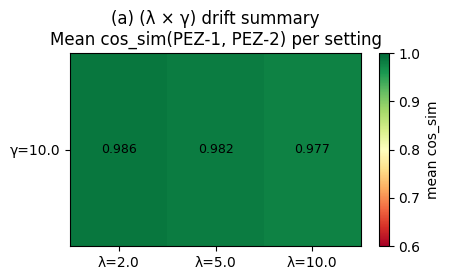

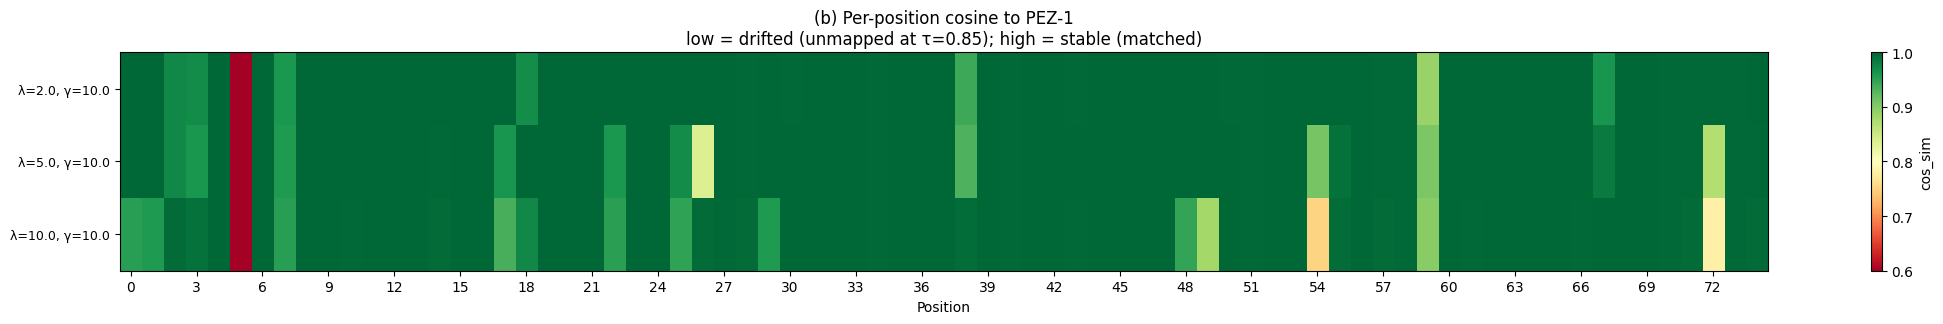

,pos,PEZ-1,"λ=2.0, γ=10.0","λ=5.0, γ=10.0","λ=10.0, γ=10.0"
0,0,"'�' (0.14), 'wie' (0.14), '🍋' (0.14)","'�' (0.14), '🍋' (0.14), 'wie' (0.14)","'wie' (0.14), '�' (0.14), '🍋' (0.14)","'wie' (0.14), 'allez' (0.14), '�' (0.14)"
1,1,"'more' (0.18), 'where' (0.17), 'how' (0.17)","'more' (0.18), 'where' (0.17), 'how' (0.17)","'more' (0.17), 'where' (0.17), 'how' (0.16)","'more' (0.17), 'me' (0.16), 'how' (0.16)"
2,2,"'canyon' (0.14), 'endeav' (0.14), 'vancou' (0.14)","'��' (0.15), 'daim' (0.14), 'khal' (0.14)","'canyon' (0.14), 'khal' (0.14), 'utter' (0.14)","'utter' (0.14), 'endeav' (0.14), 'vancou' (0.14)"
3,3,"'wee' (0.14), '«' (0.14), '€' (0.14)","'?@' (0.14), '«' (0.14), 'wiz' (0.14)","'determining' (0.15), '«' (0.14), '?@' (0.14)","'«' (0.14), 'l' (0.14), '€' (0.14)"
4,4,"'cm' (0.14), 'diamon' (0.14), '(!)' (0.13)","'cm' (0.14), 'diamon' (0.14), 'edi' (0.13)","'diamon' (0.14), 'cm' (0.14), 'vo' (0.13)","'cm' (0.14), 'diamon' (0.14), 'edi' (0.13)"
...,...,...,...,...,...
70,70,"'pirate' (0.16), 'arca' (0.15), 'papua' (0.14)","'pirate' (0.16), 'arca' (0.15), '«' (0.14)","'pirate' (0.16), 'arca' (0.15), '«' (0.14)","'pirate' (0.16), 'arca' (0.15), '«' (0.14)"
71,71,"'bpl' (0.15), '<sp>' (0.14), 'qatar' (0.14)","'<sp>' (0.19), 'bpl' (0.15), 'cfl' (0.14)","'<sp>' (0.18), 'bpl' (0.15), 'qatar' (0.14)","'<sp>' (0.19), 'bpl' (0.15), 'cfl' (0.14)"
72,72,"'awp' (0.15), 'mowx' (0.15), 'cfp' (0.15)","'cfp' (0.16), 'airdrop' (0.15), 'mowx' (0.15)","'nbaf' (0.17), 'hipstamatic' (0.17), 'ajaydevg...","'hipstamatic' (0.20), 'ajaydevgn' (0.18), 'nba..."
73,73,"'pirate' (0.16), 'qatar' (0.15), 'reading' (0.15)","'<sp>' (0.17), 'pirate' (0.16), 'reading' (0.15)","'<sp>' (0.16), 'pirate' (0.16), 'qatar' (0.15)","'<sp>' (0.17), 'pirate' (0.16), 'qatar' (0.15)"


,Setting,λ,γ,Projected prompt
0,PEZ-1 (source),—,—,� more canyonwee cm cuz ::daze voycollective n...
1,"PEZ-2 (λ=2.0, γ=10.0)",2.0,10.0,� more ��?@ cm karting ::daze voycollective nd...
2,"PEZ-2 (λ=5.0, γ=10.0)",5.0,10.0,wie more canyondetermining diamonkarting ::daz...
3,"PEZ-2 (λ=10.0, γ=10.0)",10.0,10.0,wie more utter « cm reliable ::daze voycollect...


Saved Vis #1 → outputs/colab_oneshot/vis1_prompt_evolution.html
Saved Vis #1a → outputs/colab_oneshot/vis1a_lambda_gamma_drift_summary.png
Saved Vis #1b → outputs/colab_oneshot/vis1b_position_drift.png


In [18]:
# 9. Visualization 1 — PEZ-1 → PEZ-2 evolution across the full (λ, γ) grid
#
# Three views, in increasing fidelity to what continuous-PEZ encodes:
#   (a) (λ × γ) 2D drift summary heatmap — single scalar (mean cosine
#       to PEZ-1) per (λ, γ) cell. The (λ, γ)-centric overview.
#   (b) Per-position cosine heatmap — 12 rows × N cols, the detail view.
#   (c) Top-3 nearest vocab per position — surfaces between-vocab
#       embeddings.
import base64
import difflib
import io

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from IPython.display import display, HTML

_token_emb = sd_components['text_encoder'].text_model.embeddings.token_embedding
src_emb_flat = source_embeddings.squeeze(0).float()              # [N, D]
N = src_emb_flat.shape[0]

# --- (a) (λ × γ) drift summary heatmap ---
# One scalar per (λ, γ): mean cosine similarity to PEZ-1 across all
# positions. Higher mean = embedding stayed close to PEZ-1 overall.
mean_cos = np.zeros((len(GAMMA_GRID), len(LAMBDA_GRID)))
for i, gam in enumerate(GAMMA_GRID):
    for j, lam in enumerate(LAMBDA_GRID):
        tgt_emb, _ = pez_2_results[(lam, gam)]
        sims = F.cosine_similarity(src_emb_flat, tgt_emb.squeeze(0).float(), dim=-1)
        mean_cos[i, j] = sims.mean().item()

fig_a, ax_a = plt.subplots(figsize=(0.9 * len(LAMBDA_GRID) + 2, 0.9 * len(GAMMA_GRID) + 2))
im_a = ax_a.imshow(mean_cos, aspect='auto', cmap='RdYlGn', vmin=0.6, vmax=1.0)
ax_a.set_xticks(range(len(LAMBDA_GRID)))
ax_a.set_xticklabels([f'λ={l}' for l in LAMBDA_GRID])
ax_a.set_yticks(range(len(GAMMA_GRID)))
ax_a.set_yticklabels([f'γ={g}' for g in GAMMA_GRID])
ax_a.set_title('(a) (λ × γ) drift summary\nMean cos_sim(PEZ-1, PEZ-2) per setting')
for i in range(len(GAMMA_GRID)):
    for j in range(len(LAMBDA_GRID)):
        c = 'white' if mean_cos[i, j] < 0.78 else 'black'
        ax_a.text(j, i, f'{mean_cos[i, j]:.3f}', ha='center', va='center', color=c, fontsize=9)
fig_a.colorbar(im_a, ax=ax_a, label='mean cos_sim')
fig_a.tight_layout()
fig_a.savefig(OUTPUT_DIR / 'vis1a_lambda_gamma_drift_summary.png', dpi=120, bbox_inches='tight')

buf_a = io.BytesIO()
fig_a.savefig(buf_a, format='png', dpi=120, bbox_inches='tight')
buf_a.seek(0)
heatmap_a_b64 = base64.b64encode(buf_a.read()).decode('ascii')
plt.show()

# --- (b) Per-position cosine heatmap (12 rows × N positions) ---
settings = [(lam, gam) for lam in LAMBDA_GRID for gam in GAMMA_GRID]
labels   = [f'λ={lam}, γ={gam}' for (lam, gam) in settings]

cos_matrix = []
for (lam, gam) in settings:
    tgt_emb, _ = pez_2_results[(lam, gam)]
    cos_matrix.append(
        F.cosine_similarity(src_emb_flat, tgt_emb.squeeze(0).float(), dim=-1).cpu().tolist()
    )
cos_arr = np.array(cos_matrix)
tau = edit_config.alignment_threshold

# Cap width so the figure fits on screen at large N (was 0.55*N+2 →
# ~43" at N=75, unreadable). Beyond ~30 positions the per-cell text
# annotations also get cramped, so we drop them.
fig_w = max(7.0, min(22.0, 0.30 * N + 2.0))
fig_b, ax_b = plt.subplots(figsize=(fig_w, 0.45 * len(settings) + 2.0))
im_b = ax_b.imshow(cos_arr, aspect='auto', cmap='RdYlGn', vmin=0.6, vmax=1.0)
# Thin x-axis labels at large N (~25 ticks max).
_xtick_step = max(1, N // 25)
_xticks = list(range(0, N, _xtick_step))
ax_b.set_xticks(_xticks)
ax_b.set_xticklabels(_xticks)
ax_b.set_yticks(range(len(settings)))
ax_b.set_yticklabels(labels, fontsize=9)
ax_b.set_xlabel('Position')
ax_b.set_title(f'(b) Per-position cosine to PEZ-1\n'
               f'low = drifted (unmapped at τ={tau:.2f}); high = stable (matched)')
if N <= 30:
    for i in range(len(settings)):
        for j in range(N):
            v = cos_arr[i, j]
            c = 'white' if v < 0.78 else 'black'
            weight = 'bold' if v < tau else 'normal'
            ax_b.text(j, i, f'{v:.2f}', ha='center', va='center',
                      color=c, fontsize=7, fontweight=weight)
fig_b.colorbar(im_b, ax=ax_b, label='cos_sim')
fig_b.tight_layout()
fig_b.savefig(OUTPUT_DIR / 'vis1b_position_drift.png', dpi=120, bbox_inches='tight')

buf_b = io.BytesIO()
fig_b.savefig(buf_b, format='png', dpi=120, bbox_inches='tight')
buf_b.seek(0)
heatmap_b_b64 = base64.b64encode(buf_b.read()).decode('ascii')
plt.show()

# --- (c) Top-3 nearest vocab per position ---
def _topk_nearest(emb, k=3):
    e = emb.squeeze(0).float()
    e_n = F.normalize(e, dim=-1)
    vocab_n = F.normalize(_token_emb.weight.float(), dim=-1)
    sims = e_n @ vocab_n.T
    vals, ids = sims.topk(k, dim=-1)
    return [
        [
            (tokenizer.decode([int(tid)], skip_special_tokens=True).strip() or '<sp>',
             float(v))
            for tid, v in zip(ids[pos].tolist(), vals[pos].tolist())
        ]
        for pos in range(e.shape[0])
    ]

topk_pez1 = _topk_nearest(source_embeddings)
topk_pez2 = {(lam, gam): _topk_nearest(emb) for (lam, gam), (emb, _) in pez_2_results.items()}

def _fmt_topk(entries):
    return ', '.join(f'{tok!r} ({val:.2f})' for tok, val in entries)

tk_rows = []
for pos in range(N):
    row = {'pos': pos, 'PEZ-1': _fmt_topk(topk_pez1[pos])}
    for (lam, gam) in settings:
        row[f'λ={lam}, γ={gam}'] = _fmt_topk(topk_pez2[(lam, gam)][pos])
    tk_rows.append(row)
topk_df = pd.DataFrame(tk_rows)
display(HTML('<h4>(c) Top-3 nearest vocab per position</h4>'))
display(topk_df)

# --- Projected-prompt table for human inspection ---
proj_rows = [{'Setting': 'PEZ-1 (source)', 'λ': '—', 'γ': '—', 'Projected prompt': pez_1_prompt}]
for (lam, gam) in settings:
    _, prompt = pez_2_results[(lam, gam)]
    proj_rows.append({'Setting': f'PEZ-2 (λ={lam}, γ={gam})', 'λ': lam, 'γ': gam, 'Projected prompt': prompt})
proj_df = pd.DataFrame(proj_rows)
display(HTML('<h4>Projected prompts (nearest-vocab decode for inspection only)</h4>'))
display(proj_df)

# --- Persist Vis #1 — full self-contained HTML ---
vis1_full_html = (
    '<!doctype html><meta charset="utf-8">'
    '<style>'
    'body{font-family:sans-serif;max-width:1400px;margin:2em auto;padding:0 1em}'
    'table{border-collapse:collapse;margin:1em 0;font-size:.78em}'
    'td,th{padding:.3em .5em;border:1px solid #ddd;vertical-align:top}'
    'img{max-width:100%}'
    '</style>'
    f'<h3>Vis #1 — PEZ-1 → PEZ-2 evolution across (λ, γ) grid</h3>'
    f'<p><b>Instruction:</b> {INSTRUCTION!r}</p>'
    f'<p><b>PEZ-1 (projected):</b> {pez_1_prompt}</p>'
    f'<h4>(a) (λ × γ) drift summary heatmap</h4>'
    f'<img src="data:image/png;base64,{heatmap_a_b64}">'
    f'<h4>(b) Per-position cosine heatmap</h4>'
    f'<img src="data:image/png;base64,{heatmap_b_b64}">'
    f'<h4>Projected-prompt table</h4>{proj_df.to_html(index=False)}'
    f'<h4>(c) Top-3 nearest vocab per position</h4>'
    f'{topk_df.to_html(index=False, escape=True)}'
)
(OUTPUT_DIR / 'vis1_prompt_evolution.html').write_text(vis1_full_html, encoding='utf-8')
print(f"Saved Vis #1 → {OUTPUT_DIR / 'vis1_prompt_evolution.html'}")
print(f"Saved Vis #1a → {OUTPUT_DIR / 'vis1a_lambda_gamma_drift_summary.png'}")
print(f"Saved Vis #1b → {OUTPUT_DIR / 'vis1b_position_drift.png'}")

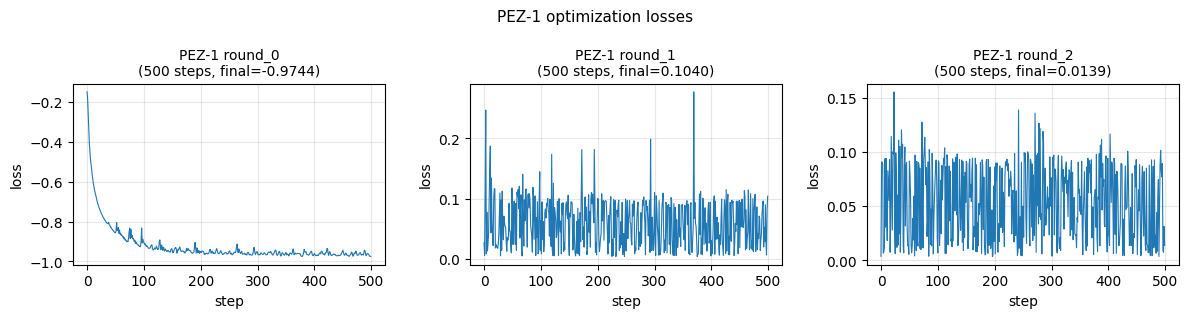

Saved → outputs/colab_oneshot/vis_pez1_losses.png


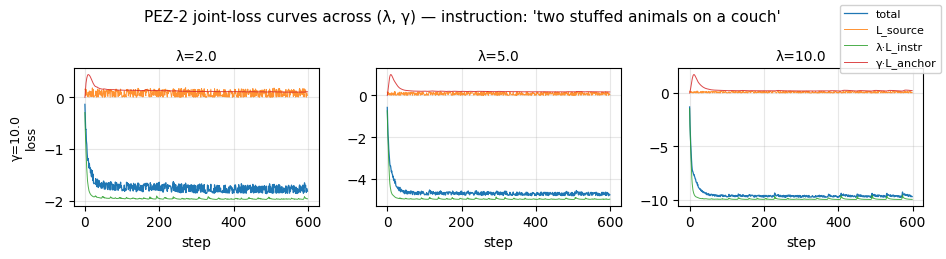

Saved → outputs/colab_oneshot/vis_pez2_losses.png


In [19]:
# 9b. Visualization — PEZ-1 / PEZ-2 loss curves
#
# PEZ-1: one subplot per round (single curve each — Round 0 is CLIP-cosine,
# Rounds 1+ are SDS-CFG; different y-scales so they live on separate axes).
# PEZ-2: per (λ, γ) cell, four curves (total, L_source, λ·L_instr,
# γ·L_anchor) — components are *weighted* so they sum to total.
#
# Cache-hit runs leave pez_1_losses / pez_2_losses empty for that artifact;
# this cell prints a message and skips the affected sub-plot in that case.
import matplotlib.pyplot as plt
import numpy as np

# --- PEZ-1 loss curves ---
if pez_1_losses:
    rounds = sorted(pez_1_losses.keys())
    fig_p1, axes_p1 = plt.subplots(
        1, len(rounds), figsize=(4.0 * len(rounds), 3.2), squeeze=False,
    )
    for i, r in enumerate(rounds):
        ax = axes_p1[0, i]
        loss = pez_1_losses[r]
        ax.plot(loss, linewidth=0.8)
        ax.set_title(f'PEZ-1 {r}\n({len(loss)} steps, final={loss[-1]:.4f})', fontsize=10)
        ax.set_xlabel('step'); ax.set_ylabel('loss')
        ax.grid(True, alpha=0.3)
    fig_p1.suptitle('PEZ-1 optimization losses', fontsize=11)
    fig_p1.tight_layout()
    fig_p1.savefig(OUTPUT_DIR / 'vis_pez1_losses.png', dpi=120, bbox_inches='tight')
    plt.show()
    print(f"Saved → {OUTPUT_DIR / 'vis_pez1_losses.png'}")
else:
    print('PEZ-1 losses unavailable (cache hit) — skipping PEZ-1 loss plot.')

# --- PEZ-2 loss curves: faceted (γ rows × λ cols), each cell has 4 curves ---
if pez_2_losses:
    fig_p2, axes_p2 = plt.subplots(
        len(GAMMA_GRID), len(LAMBDA_GRID),
        figsize=(3.2 * len(LAMBDA_GRID), 2.6 * len(GAMMA_GRID)),
        squeeze=False, sharex=True,
    )
    for i, gam in enumerate(GAMMA_GRID):
        for j, lam in enumerate(LAMBDA_GRID):
            ax = axes_p2[i, j]
            d = pez_2_losses.get((lam, gam))
            if d is None:
                ax.text(0.5, 0.5, 'cache hit\n(no losses)',
                        ha='center', va='center', transform=ax.transAxes, fontsize=9)
                ax.set_xticks([]); ax.set_yticks([])
            else:
                steps = np.arange(len(d['total']))
                ax.plot(steps, d['total'],        label='total',        linewidth=0.9)
                ax.plot(steps, d['l_source'],     label='L_source',     linewidth=0.7, alpha=0.85)
                ax.plot(steps, d['lam_l_instr'],  label='λ·L_instr',    linewidth=0.7, alpha=0.85)
                ax.plot(steps, d['gam_l_anchor'], label='γ·L_anchor',   linewidth=0.7, alpha=0.85)
                ax.grid(True, alpha=0.3)
                if i == 0:
                    ax.set_title(f'λ={lam}', fontsize=10)
                if j == 0:
                    ax.set_ylabel(f'γ={gam}\nloss', fontsize=9)
                if i == len(GAMMA_GRID) - 1:
                    ax.set_xlabel('step')
    # Single shared legend (top-right cell)
    handles, labels = axes_p2[0, -1].get_legend_handles_labels()
    if handles:
        fig_p2.legend(handles, labels, loc='upper right', fontsize=8, framealpha=0.9)
    fig_p2.suptitle(
        f'PEZ-2 joint-loss curves across (λ, γ) — instruction: {INSTRUCTION!r}',
        fontsize=11,
    )
    fig_p2.tight_layout()
    fig_p2.savefig(OUTPUT_DIR / 'vis_pez2_losses.png', dpi=120, bbox_inches='tight')
    plt.show()
    print(f"Saved → {OUTPUT_DIR / 'vis_pez2_losses.png'}")
else:
    print('PEZ-2 losses unavailable (all cache hits) — skipping PEZ-2 loss plot.')

In [20]:
# 10b. Method-path source-side invariants. Computed once and reused
#      across the (λ, γ, cross_replace_steps) sweep — see the
#      cached_* kwargs of run_edit. Depends on PEZ-1's source_embeddings,
#      so this cell lives *after* PEZ-1/PEZ-2; the BLIP baseline path
#      doesn't need it (it provides cached_* explicitly).
print('Pre-computing method-path invariants (z_T + source/uncond encodings)...')
pez_inputs = prepare_p2p_inputs(
    image=source_image,
    source_embeddings=source_embeddings,
    sd_components=sd_components,
    edit_config=_base_edit_cfg,
)
print(f'  z_T shape: {tuple(pez_inputs["z_T"].shape)}; reusing across all sweep cells')

Pre-computing method-path invariants (z_T + source/uncond encodings)...


DDIM Inversion: 100%|██████████| 50/50 [00:03<00:00, 13.23it/s]

  z_T shape: (1, 4, 64, 64); reusing across all sweep cells


In [21]:
# 11. Run the full 3D grid: |λ|·|γ|·|cross_replace_steps| edits.
#     Cost-aware order: PEZ-2 outer (already done above), editing inner.
#
#     Hoist (λ, γ)-invariant work out of the inner cross_replace_steps
#     loop (Bug #8 fix): target_emb encoding and per-position alignment
#     both depend only on (source_emb, target_emb), so they're computed
#     once per outer cell and threaded in as cached_* kwargs.
from src.splice.align import align_pez_prompts as _align

_src_for_align = source_embeddings.squeeze(0) if source_embeddings.ndim == 3 else source_embeddings

grid_results = {}  # (λ, γ, cross_replace) -> edited_image
for (lam, gam), (target_emb, _) in pez_2_results.items():
    _tgt_dev = target_emb.to(device=_device)
    _cached_tgt_emb = encode_continuous_prompt(
        _tgt_dev, sd_components['text_encoder'], tokenizer, _dtype,
    )
    _tgt_for_align = _tgt_dev.squeeze(0) if _tgt_dev.ndim == 3 else _tgt_dev
    _cached_align = _align(
        _src_for_align, _tgt_for_align,
        threshold=_base_edit_cfg.alignment_threshold,
        method=_base_edit_cfg.alignment_method,
    )
    for k2_val in KNOB_2_GRID:
        print(f'Edit [λ={lam}, γ={gam}, cross_replace={k2_val}]')
        grid_results[(lam, gam, k2_val)] = run_edit(
            source_embeddings, target_emb, k2_val,
            cached_target_emb=_cached_tgt_emb,
            cached_alignment=_cached_align,
        )
print(f'\nGenerated {len(grid_results)} method edits.')


Edit [λ=2.0, γ=10.0, cross_replace=0.6]
Edit [λ=2.0, γ=10.0, cross_replace=0.4]
Edit [λ=2.0, γ=10.0, cross_replace=0.2]
Edit [λ=5.0, γ=10.0, cross_replace=0.6]
Edit [λ=5.0, γ=10.0, cross_replace=0.4]
Edit [λ=5.0, γ=10.0, cross_replace=0.2]
Edit [λ=10.0, γ=10.0, cross_replace=0.6]
Edit [λ=10.0, γ=10.0, cross_replace=0.4]
Edit [λ=10.0, γ=10.0, cross_replace=0.2]

Generated 9 method edits.


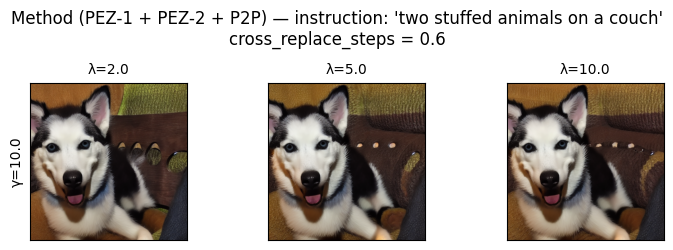

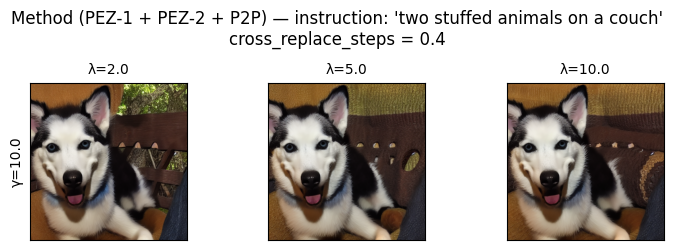

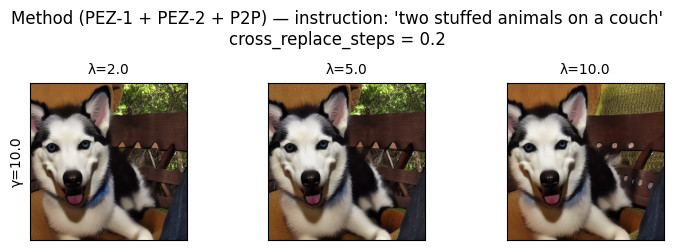

Saved Vis #2A → ['vis2a_method_grid_xrep0.6.png', 'vis2a_method_grid_xrep0.4.png', 'vis2a_method_grid_xrep0.2.png']


In [22]:
# 12. Visualization 2A — three (λ × γ) image panels, one per
#     cross_replace_steps. (λ, γ)-centric: λ on x-axis, γ on y-axis.
import matplotlib.pyplot as plt

panel_paths = []
for k2_val in KNOB_2_GRID:
    fig, axes = plt.subplots(
        len(GAMMA_GRID), len(LAMBDA_GRID),
        figsize=(2.5 * len(LAMBDA_GRID), 2.5 * len(GAMMA_GRID)),
        squeeze=False,
    )
    for i, gam in enumerate(GAMMA_GRID):
        for j, lam in enumerate(LAMBDA_GRID):
            ax = axes[i, j]
            ax.imshow(grid_results[(lam, gam, k2_val)])
            if i == 0:
                ax.set_title(f'λ={lam}', fontsize=10)
            if j == 0:
                ax.set_ylabel(f'γ={gam}', fontsize=10)
            ax.set_xticks([]); ax.set_yticks([])
    fig.suptitle(
        f'Method (PEZ-1 + PEZ-2 + P2P) — instruction: {INSTRUCTION!r}\n'
        f'cross_replace_steps = {k2_val}',
        fontsize=12,
    )
    fig.tight_layout()
    out_path = OUTPUT_DIR / f'vis2a_method_grid_xrep{k2_val}.png'
    fig.savefig(out_path, dpi=120, bbox_inches='tight')
    panel_paths.append(out_path)
    plt.show()
print(f'Saved Vis #2A → {[p.name for p in panel_paths]}')

Saved Vis #2B → outputs/colab_oneshot/vis2b_strip_comparison.png


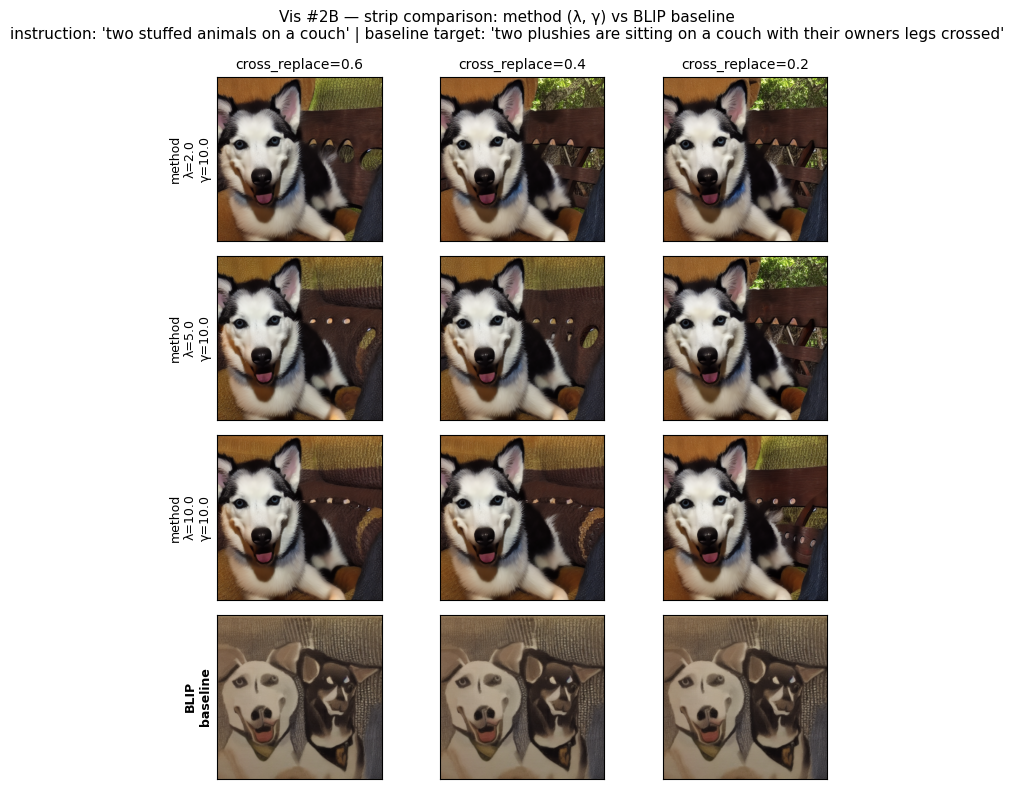

In [23]:
# 17. Visualization 2B — strip comparison: each (λ, γ) operating point
#     gets a 1×3 row of edits across cross_replace_steps, paired with
#     the BLIP-baseline strip. Mega-figure with 13 rows × 3 cols.
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    len(LAMBDA_GRID) * len(GAMMA_GRID) + 1,        # 12 method rows + 1 baseline row
    len(KNOB_2_GRID),                                # 3 cross_replace_steps cols
    figsize=(2.5 * len(KNOB_2_GRID), 2.0 * (len(LAMBDA_GRID) * len(GAMMA_GRID) + 1)),
    squeeze=False,
)

# Header row: cross_replace_steps labels
for j, k2_val in enumerate(KNOB_2_GRID):
    axes[0, j].set_title(f'cross_replace={k2_val}', fontsize=10)

# Method rows: ordered by (λ, γ) — γ outer, λ inner so visually similar
# γs are grouped together (matching the panel layout in Vis #2A).
row = 0
for gam in GAMMA_GRID:
    for lam in LAMBDA_GRID:
        for j, k2_val in enumerate(KNOB_2_GRID):
            ax = axes[row, j]
            ax.imshow(grid_results[(lam, gam, k2_val)])
            ax.set_xticks([]); ax.set_yticks([])
        axes[row, 0].set_ylabel(f'method\nλ={lam}\nγ={gam}', fontsize=9)
        row += 1

# Baseline row (last)
for j, k2_val in enumerate(KNOB_2_GRID):
    ax = axes[row, j]
    ax.imshow(blip_results[k2_val])
    ax.set_xticks([]); ax.set_yticks([])
axes[row, 0].set_ylabel(f'BLIP\nbaseline', fontsize=9, fontweight='bold')

fig.suptitle(
    f'Vis #2B — strip comparison: method (λ, γ) vs BLIP baseline\n'
    f'instruction: {INSTRUCTION!r} | baseline target: {MANUAL_TARGET_PROMPT!r}',
    fontsize=11,
)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'vis2b_strip_comparison.png', dpi=110, bbox_inches='tight')
print(f"Saved Vis #2B → {OUTPUT_DIR / 'vis2b_strip_comparison.png'}")
plt.show()

Saved Vis #2C → outputs/colab_oneshot/vis2c_cross_replace_cycle.gif


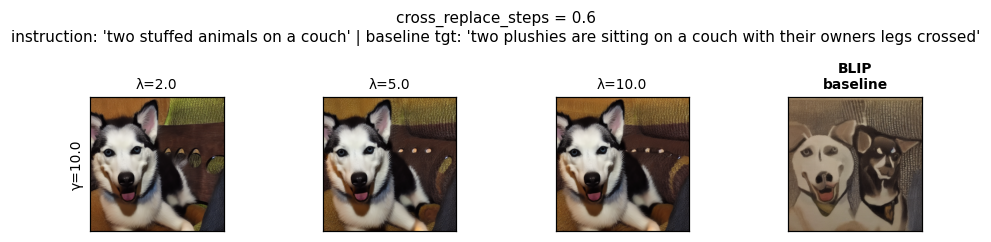

In [24]:
# 18. Visualization 2C — GIF cycling cross_replace_steps. Each frame
#     is a (γ × λ) method panel + BLIP-baseline sidecar cell, so the
#     reader sees method-vs-baseline at every cross_replace_steps step.
import matplotlib.pyplot as plt
import io

frames = []
target_size = None
for k2_val in KNOB_2_GRID:
    # Layout: (γ rows) × (λ + 1 cols), where the +1 col is the baseline.
    fig, axes = plt.subplots(
        len(GAMMA_GRID), len(LAMBDA_GRID) + 1,
        figsize=(2.2 * (len(LAMBDA_GRID) + 1), 2.2 * len(GAMMA_GRID)),
        squeeze=False,
    )
    for i, gam in enumerate(GAMMA_GRID):
        for j, lam in enumerate(LAMBDA_GRID):
            ax = axes[i, j]
            ax.imshow(grid_results[(lam, gam, k2_val)])
            if i == 0:
                ax.set_title(f'λ={lam}', fontsize=9)
            if j == 0:
                ax.set_ylabel(f'γ={gam}', fontsize=9)
            ax.set_xticks([]); ax.set_yticks([])
        # Baseline cell (rightmost column). Show it only on the middle
        # row to avoid repetition, and grey out the other baseline cells.
        ax_b = axes[i, len(LAMBDA_GRID)]
        if i == len(GAMMA_GRID) // 2:
            ax_b.imshow(blip_results[k2_val])
            ax_b.set_title('BLIP\nbaseline', fontsize=9, fontweight='bold')
        else:
            ax_b.set_facecolor('#f5f5f5')
        ax_b.set_xticks([]); ax_b.set_yticks([])

    fig.suptitle(
        f'cross_replace_steps = {k2_val}\n'
        f'instruction: {INSTRUCTION!r} | baseline tgt: {MANUAL_TARGET_PROMPT!r}',
        fontsize=10,
    )
    fig.tight_layout()
    # Render to PIL via in-memory PNG.
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=110, bbox_inches='tight')
    plt.close(fig)
    buf.seek(0)
    frame = Image.open(buf).convert('RGB')
    if target_size is None:
        target_size = frame.size
    else:
        frame = frame.resize(target_size)
    frames.append(frame)

# Save GIF — 1.5s per frame, infinite loop.
gif_path = OUTPUT_DIR / 'vis2c_cross_replace_cycle.gif'
frames[0].save(
    gif_path, save_all=True, append_images=frames[1:],
    duration=1500, loop=0,
)
print(f"Saved Vis #2C → {gif_path}")
# Show the first frame inline so the reader sees the layout.
display(frames[0])

In [25]:
# 19. Save per-cell PNGs + run_metadata.json. Combined with the composed
#     figures (Vis #2A panels, Vis #2B strip comparison, Vis #2C GIF,
#     Vis #3 baseline strip) and the prompt-evolution HTML (Vis #1),
#     the output directory is a self-contained record of the run.
import json
import datetime

source_image.save(OUTPUT_DIR / 'source.png')
for (lam, gam, k2), img in grid_results.items():
    img.save(OUTPUT_DIR / f'method_lam{lam}_gam{gam}_xrep{k2}.png')
for k2, img in blip_results.items():
    img.save(OUTPUT_DIR / f'baseline_xrep{k2}.png')

# Persist PEZ-1's expensive outputs alongside this run's artifacts.
# These are also in cache/pez_source_prompts/ keyed by image+config hash,
# but copies here keep the run output directory self-contained for
# reproducibility and easy hand-off.
import torch as _torch_save
_torch_save.save(
    source_embeddings.detach().cpu(),
    OUTPUT_DIR / 'pez_1_source_embeddings.pt',
)
_torch_save.save(
    [nt.detach().cpu() for nt in null_text_per_timestep],
    OUTPUT_DIR / 'pez_1_null_text_per_timestep.pt',
)
print(f'  Saved PEZ-1 source_embeddings: shape {tuple(source_embeddings.shape)}')
print(f'  Saved PEZ-1 null_text_per_timestep: {len(null_text_per_timestep)} tensors '
      f'each shape {tuple(null_text_per_timestep[0].shape)}')

# Per-position cosine similarity between PEZ-1 and each PEZ-2 output
# — the per-position drift summary is the v1 analog of token-ID overlap.
import torch.nn.functional as _F
def _per_position_cos(src, tgt):
    a = src.squeeze(0).float()
    b = tgt.squeeze(0).float()
    return _F.cosine_similarity(a, b, dim=-1).cpu().tolist()

metadata = {
    'timestamp_utc': datetime.datetime.utcnow().isoformat() + 'Z',
    'image_path': IMAGE_PATH,
    'image_url': IMAGE_URL,
    'instruction': INSTRUCTION,
    'manual_target_prompt': MANUAL_TARGET_PROMPT,
    'blip_caption': BLIP_SOURCE_PROMPT,
    'pez_1': {
        'embeddings_shape': list(source_embeddings.shape),
        'projected_prompt': pez_1_prompt,
    },
    'pez_2_results': {
        f'lam{lam}_gam{gam}': {
            'lambda_instruction': lam,
            'gamma_anchor': gam,
            'projected_prompt': prompt,
            'per_position_cosine_to_pez1': _per_position_cos(source_embeddings, target_emb),
        }
        for (lam, gam), (target_emb, prompt) in pez_2_results.items()
    },
    'lambda_grid': LAMBDA_GRID,
    'gamma_grid':  GAMMA_GRID,
    'knob_2_grid': list(KNOB_2_GRID),
    'model_ids': {
        'sd': edit_config.sd_model,
        'clip': CLIP_HF_ID,
        'blip': BLIP_HF_ID,
    },
    'configs': {
        'pez_1': pez_1_config.__dict__,
        'pez_2_base': {k: v for k, v in pez_2_config.__dict__.items()
                       if k not in {'lambda_instruction', 'gamma_anchor'}},
        'edit': {
            'sd_model': edit_config.sd_model,
            'ddim': edit_config.ddim.__dict__,
            'cross_attention_base': edit_config.cross_attention.__dict__,
            'alignment_method': edit_config.alignment_method,
            'alignment_threshold': edit_config.alignment_threshold,
            'mode': edit_config.mode,
        },
        'local_blend': load_local_blend().__dict__,
    },
    'output_files': {
        'source':                  'source.png',
        'pez_1_source_embeddings': 'pez_1_source_embeddings.pt',
        'pez_1_null_text':         'pez_1_null_text_per_timestep.pt',
        'method_grid_cells':  [f'method_lam{lam}_gam{gam}_xrep{k2}.png'
                               for lam in LAMBDA_GRID for gam in GAMMA_GRID for k2 in KNOB_2_GRID],
        'baseline_cells':     [f'baseline_xrep{k2}.png' for k2 in KNOB_2_GRID],
        'vis1_html':          'vis1_prompt_evolution.html',
        'vis1a_drift_summary':'vis1a_lambda_gamma_drift_summary.png',
        'vis1b_heatmap':      'vis1b_position_drift.png',
        'vis2a_panels':       [f'vis2a_method_grid_xrep{k2}.png' for k2 in KNOB_2_GRID],
        'vis2b_strip':        'vis2b_strip_comparison.png',
        'vis2c_gif':          'vis2c_cross_replace_cycle.gif',
        'vis3_baseline_row':  'vis3_baseline_row.png',
    },
}
(OUTPUT_DIR / 'run_metadata.json').write_text(json.dumps(metadata, indent=2, default=str), encoding='utf-8')

n_pngs = 1 + len(grid_results) + len(blip_results) + 5  # +5 for vis1a, vis1b, 3× vis2a, vis2b
print(f'Saved {n_pngs} PNGs + 1 GIF + 1 HTML + 1 JSON to {OUTPUT_DIR}/')
print('Files:')
for p in sorted(OUTPUT_DIR.iterdir()):
    print(f'  {p.name}')

  Saved PEZ-1 source_embeddings: shape (1, 75, 768)
  Saved PEZ-1 null_text_per_timestep: 50 tensors each shape (1, 77, 768)
Saved 18 PNGs + 1 GIF + 1 HTML + 1 JSON to outputs/colab_oneshot/
Files:
  baseline_xrep0.2.png
  baseline_xrep0.4.png
  baseline_xrep0.6.png
  method_lam10.0_gam10.0_xrep0.2.png
  method_lam10.0_gam10.0_xrep0.4.png
  method_lam10.0_gam10.0_xrep0.6.png
  method_lam2.0_gam10.0_xrep0.2.png
  method_lam2.0_gam10.0_xrep0.4.png
  method_lam2.0_gam10.0_xrep0.6.png
  method_lam5.0_gam10.0_xrep0.2.png
  method_lam5.0_gam10.0_xrep0.4.png
  method_lam5.0_gam10.0_xrep0.6.png
  pez_1_null_text_per_timestep.pt
  pez_1_source_embeddings.pt
  run_metadata.json
  source.png
  vis1_prompt_evolution.html
  vis1a_lambda_gamma_drift_summary.png
  vis1b_position_drift.png
  vis2a_method_grid_xrep0.2.png
  vis2a_method_grid_xrep0.4.png
  vis2a_method_grid_xrep0.6.png
  vis2b_strip_comparison.png
  vis2c_cross_replace_cycle.gif
  vis3_baseline_row.png
  vis_pez1_losses.png
  vis_pez2_l

/tmp/ipykernel_1133/473607181.py:40: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  'timestamp_utc': datetime.datetime.utcnow().isoformat() + 'Z',


In [ ]:
# Evaluate results with comprehensive metrics
from src.metrics import compute_ssim, compute_lpips, clip_text_image_similarity
from skimage.metrics import peak_signal_noise_ratio
from pathlib import Path
from PIL import Image
import numpy as np

# Load saved images for evaluation
OUTPUT_DIR = Path('outputs/colab_oneshot')
source_img = Image.open(OUTPUT_DIR / 'source.png')

# Select representative method edit (middle of the grid: λ=2.0, γ=10.0, cross_replace=0.4)
method_img = Image.open(OUTPUT_DIR / 'method_lam2.0_gam10.0_xrep0.4.png')

# Select corresponding baseline edit
baseline_img = Image.open(OUTPUT_DIR / 'baseline_xrep0.4.png')

print("Evaluating Method Edit (PEZ + P2P):")
psnr_method = peak_signal_noise_ratio(np.array(source_img), np.array(method_img), data_range=255.0)
ssim_method = compute_ssim(source_img, method_img)
lpips_method = compute_lpips(source_img, method_img)
clip_sim_method = clip_text_image_similarity(method_img, INSTRUCTION)

print(f"PSNR: {psnr_method:.2f} dB")
print(f"SSIM: {ssim_method:.4f}")
print(f"LPIPS: {lpips_method:.4f}")
print(f"CLIP Text-Image Similarity: {clip_sim_method:.4f}")

print("\nEvaluating Baseline Edit (BLIP + Manual Prompt):")
psnr_baseline = peak_signal_noise_ratio(np.array(source_img), np.array(baseline_img), data_range=255.0)
ssim_baseline = compute_ssim(source_img, baseline_img)
lpips_baseline = compute_lpips(source_img, baseline_img)
clip_sim_baseline = clip_text_image_similarity(baseline_img, MANUAL_TARGET_PROMPT)

print(f"PSNR: {psnr_baseline:.2f} dB")
print(f"SSIM: {ssim_baseline:.4f}")
print(f"LPIPS: {lpips_baseline:.4f}")
print(f"CLIP Text-Image Similarity: {clip_sim_baseline:.4f}")

print("\nComparison (Method vs Baseline):")
print(f"PSNR: Method {psnr_method:.2f} vs Baseline {psnr_baseline:.2f} ({'Better' if psnr_method > psnr_baseline else 'Worse'} preservation)")
print(f"SSIM: Method {ssim_method:.4f} vs Baseline {ssim_baseline:.4f} ({'Better' if ssim_method > ssim_baseline else 'Worse'} structure)")
print(f"LPIPS: Method {lpips_method:.4f} vs Baseline {lpips_baseline:.4f} ({'Better' if lpips_method < lpips_baseline else 'Worse'} perception)")
print(f"CLIP Similarity: Method {clip_sim_method:.4f} vs Baseline {clip_sim_baseline:.4f} ({'Better' if clip_sim_method > clip_sim_baseline else 'Worse'} semantic match)")